CSC246 Final Project

Minh Phan (mphan4)
Marco Betti (mbetti)

Libraries Used (Data is already downloaded as CSV)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Layers Implemented (Similar structure to Torch): Conv2d, MaxPool2d, Flatten, Linear, Softmax, ReLU. Each layer has a forward method and a backward method which computes the gradient. Then the paramters of only the Conv2d and Linear layer is updated using gradient descent after backprop.

In [2]:
class Conv2d:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.weights = np.random.normal(0.0, 0.1, (out_channels, in_channels, kernel_size, kernel_size))
        self.bias = np.random.normal(0.0, 0.1, (out_channels))

    def forward(self, x):
        batch_size, _, height, width = x.shape
        self.x = np.pad(x, [(0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)], mode='constant')
        out_height = (height + 2 * self.padding - self.kernel_size) // self.stride + 1
        out_width = (width + 2 * self.padding - self.kernel_size) // self.stride + 1

        self.x_col = self.im2col(self.x, self.kernel_size, self.stride)
        w_col = self.weights.reshape(self.out_channels, -1)

        out = w_col @ self.x_col + self.bias.reshape(-1, 1)
        out = out.reshape(self.out_channels, out_height, out_width, batch_size)
        out = out.transpose(3, 0, 1, 2)

        return out

    def backward(self, d_out):
        d_out = d_out.transpose(1, 2, 3, 0).reshape(self.out_channels, -1)

        d_w = d_out @ self.x_col.T
        self.d_weights = d_w.reshape(self.weights.shape)
        self.d_bias = np.sum(d_out, axis=1)

        d_x_col = self.weights.reshape(self.out_channels, -1).T @ d_out
        d_x = self.col2im(d_x_col, self.x.shape, self.kernel_size, self.stride)

        if self.padding > 0:
            d_x = d_x[:, :, self.padding:-self.padding, self.padding:-self.padding]

        return d_x

    def im2col(self, x, kernel_size, stride):
        batch_size, in_channels, height, width = x.shape
        out_height = (height - kernel_size) // stride + 1
        out_width = (width - kernel_size) // stride + 1

        i0 = np.repeat(np.arange(kernel_size), kernel_size)
        i1 = stride * np.repeat(np.arange(out_height), out_width)
        j0 = np.tile(np.arange(kernel_size), kernel_size)
        j1 = stride * np.tile(np.arange(out_width), out_height)

        i = i0.reshape(-1, 1) + i1.reshape(1, -1)
        j = j0.reshape(-1, 1) + j1.reshape(1, -1)

        k = np.repeat(np.arange(in_channels), kernel_size * kernel_size).reshape(-1, 1)

        cols = x[:, k, i, j].transpose(1, 2, 0).reshape(kernel_size * kernel_size * in_channels, -1)
        return cols

    def col2im(self, x_col, x_shape, kernel_size, stride):
        batch_size, in_channels, height, width = x_shape
        out_height = (height - kernel_size) // stride + 1
        out_width = (width - kernel_size) // stride + 1

        i0 = np.repeat(np.arange(kernel_size), kernel_size)
        i1 = stride * np.repeat(np.arange(out_height), out_width)
        j0 = np.tile(np.arange(kernel_size), kernel_size)
        j1 = stride * np.tile(np.arange(out_width), out_height)

        i = i0.reshape(-1, 1) + i1.reshape(1, -1)
        j = j0.reshape(-1, 1) + j1.reshape(1, -1)

        k = np.repeat(np.arange(in_channels), kernel_size * kernel_size).reshape(-1, 1)

        x_col = x_col.reshape(kernel_size * kernel_size * in_channels, -1, batch_size)
        x_col = x_col.transpose(2, 0, 1)

        x_im = np.zeros(x_shape)
        np.add.at(x_im, (slice(None), k, i, j), x_col)

        return x_im

In [3]:
class MaxPool2d:
    def __init__(self, kernel_size, stride=None, padding=0):
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, x):
        self.x = np.pad(x, [(0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)], mode='constant')
        batch_size, channels, height, width = self.x.shape
        out_height = (height - self.kernel_size) // self.stride + 1
        out_width = (width - self.kernel_size) // self.stride + 1
        
        self.output = np.zeros((batch_size, channels, out_height, out_width))
        self.max_indices = np.zeros((batch_size, channels, out_height, out_width, 2), dtype=int)

        for n in range(batch_size):
            for c in range(channels):
                for h in range(out_height):
                    for w in range(out_width):
                        h_start = h * self.stride
                        w_start = w * self.stride
                        h_end = h_start + self.kernel_size
                        w_end = w_start + self.kernel_size
                        window = self.x[n, c, h_start:h_end, w_start:w_end]
                        self.output[n, c, h, w] = np.max(window)
                        max_pos = np.unravel_index(np.argmax(window), window.shape)
                        self.max_indices[n, c, h, w] = (h_start + max_pos[0], w_start + max_pos[1])

        return self.output

    def backward(self, d_out):
        batch_size, channels, out_height, out_width = d_out.shape
        d_x = np.zeros_like(self.x)

        for n in range(batch_size):
            for c in range(channels):
                for h in range(out_height):
                    for w in range(out_width):
                        (h_index, w_index) = self.max_indices[n, c, h, w]
                        d_x[n, c, h_index, w_index] += d_out[n, c, h, w]

        # Remove padding from the gradient if padding was applied
        if self.padding > 0:
            return d_x[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            return d_x

In [4]:
class ReLU:
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)

    def backward(self, d_out):
        d_x = d_out.copy()  # Make a copy to avoid modifying d_out outside this scope
        d_x[self.input <= 0] = 0  # This should only apply a mask where input was <= 0
        return d_x

In [5]:
class Flatten:
    def forward(self, x):
        self.original_shape = x.shape  # Save the shape to reshape back during the backward pass
        return x.reshape(x.shape[0], -1)

    def backward(self, d_out):
        return d_out.reshape(self.original_shape)

In [6]:
class Linear:
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.normal(0.0, 0.1, (input_dim, output_dim)) 
        self.bias = np.random.normal(0.0, 0.1, (output_dim))  # zero initialization for biases

    def forward(self, x):
        self.x = x
        return np.dot(x, self.weights) + self.bias

    def backward(self, d_out):
        # Calculate gradients for weights and biases
        d_weights = np.dot(self.x.T, d_out)
        d_bias = np.sum(d_out, axis=0)

        # Store gradients in the instance for external update
        self.d_weights = d_weights
        self.d_bias = d_bias

        # Compute gradient with respect to input
        d_x = np.dot(d_out, self.weights.T)
        return d_x

In [7]:
class Softmax:
    def forward(self, logits):
        exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # numerical stability
        self.softmax = exps / np.sum(exps, axis=1, keepdims=True)
        return self.softmax

    def backward(self, d_out):
        # Gradient calculation with respect to input logits
        batch_size = d_out.shape[0]
        d_logits = self.softmax * d_out
        sum_d_logits = np.sum(d_logits, axis=1, keepdims=True)
        d_logits -= self.softmax * sum_d_logits
        return d_logits

Simple CNN Architecture for MNIST and Fashion MNIST Dataset. The structure includes:
Convolution layer with 8 output channels and kernel size of 3 with ReLU activation.
Maxpool layer with kernel size of 2.
Linear layer from MaxPool to 100 features
Linear layer to 10 features.
Softmax output.

In [8]:
class CNN():
    def __init__(self):
        self.l1 = Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.l2 = ReLU()
        self.l3 = MaxPool2d(kernel_size=2)
        self.l4 = Flatten()
        self.l5 = Linear(input_dim=1352, output_dim=100)
        self.l6 = ReLU()
        self.l7 = Linear(input_dim=100, output_dim=10)
        self.l8 = Softmax()

    def forward(self, X):
        X = self.l1.forward(X)
        X = self.l2.forward(X)
        X = self.l3.forward(X)
        X = self.l4.forward(X)
        X = self.l5.forward(X)
        X = self.l6.forward(X)
        X = self.l7.forward(X)
        X = self.l8.forward(X)
        return X

    def backward(self, dout):
        dout = self.l8.backward(dout)
        dout = self.l7.backward(dout)
        dout = self.l6.backward(dout)
        dout = self.l5.backward(dout)
        dout = self.l4.backward(dout)
        dout = self.l3.backward(dout)
        dout = self.l2.backward(dout)
        dout = self.l1.backward(dout)
        return dout
        

Utils

In [9]:
def one_hot_encode(labels, num_classes):
    """ Convert an array of labels to one-hot encoded format. """
    # Initialize the matrix with zeros.
    one_hot_labels = np.zeros((labels.size, num_classes))
    # Set the appropriate elements to one
    one_hot_labels[np.arange(labels.size), labels] = 1
    return one_hot_labels

In [10]:
def cross_entropy_loss(Y, T):
    # Adding a small number to prevent log(0).
    epsilon = 1e-12
    Y = np.clip(Y, epsilon, 1. - epsilon)
    N = Y.shape[0]
    ce_loss = -np.sum(T * np.log(Y + 1e-9)) / N
    return ce_loss

In [11]:
def delta_cross_entropy(Y, T):
    return Y - T

In [12]:
def update_parameters(layer, LR):
    layer.weights -= LR * layer.d_weights
    layer.bias -= LR * layer.d_bias

In [13]:
def zero_grad(model):
    for layer in [model.l1, model.l5, model.l7]:
        layer.d_weights = np.zeros_like(layer.weights)
        layer.d_bias = np.zeros_like(layer.bias)

In [14]:
def one_hot_encode_max(array):
    # Create an array of zeros with the same shape as the input array
    result = np.zeros_like(array)
    
    # Find the indices of the maxima for each row
    max_indices = np.argmax(array, axis=1)
    
    # Set the corresponding indices to 1
    result[np.arange(array.shape[0]), max_indices] = 1
    
    return result

In [15]:
def count_matching_max_indices(array1, array2):
    # Find indices of the maxima for each row in both arrays
    max_indices1 = np.argmax(array1, axis=1)
    max_indices2 = np.argmax(array2, axis=1)
    
    # Compare the indices for equality and count the matches
    matches = np.sum(max_indices1 == max_indices2)
    
    return matches

Preprocess Data, Train and Validate method.
In preprocess, T is converted to one_hot_encode and X is normalized.

In [16]:
def preprocess_data(data):
    #takes data return X, T
    X = data.iloc[:, 1:].values.astype(np.float32)  #
    T = data.iloc[:, 0].values.astype(int)  # Assuming the first column is 'label'
    #normalize
    X = X/255.0
    #Reshape data to (x, 1, 28, 28)
    X = X.reshape(-1, 1, 28, 28)
    T = one_hot_encode(T, 10)
    return X, T

In [17]:
def create_batches(X, T, batch_size):
    assert len(X) == len(T)
    n_batches = len(X) // batch_size
    batches = []
    for i in range(n_batches):
        batch_features = X[i * batch_size:(i + 1) * batch_size]
        batch_labels = T[i * batch_size:(i + 1) * batch_size]
        batches.append((batch_features, batch_labels))
    # Handle remainder of the data
    if len(X) % batch_size != 0:
        batch_features = X[n_batches * batch_size:]
        batch_labels = T[n_batches * batch_size:]
        batches.append((batch_features, batch_labels))
    return batches

In [18]:
def Train(train_loader, model):
    size = len(train_loader)
    batch_idx = 0

    for X, T in train_loader:
        batch_idx += 1
        zero_grad(model)
        Y = model.forward(X)
        loss = cross_entropy_loss(Y, T)
        d_out = delta_cross_entropy(Y, T)
        model.backward(d_out)

        for layer in [model.l1, model.l5, model.l7]:
            update_parameters(layer, 0.01)


        # print(f"Batch: {batch_idx}/{size}   Loss: {loss}")

In [19]:
def Validate(val_loader, model):
    size = len(val_loader) 
    correct = 0.0
    for X, T in val_loader:
        Y = model.forward(X)
        predicted = one_hot_encode_max(Y)
        correct += count_matching_max_indices(predicted, T)
    return (correct/size)

Experiment:

In [20]:
batch_size = 100
train_data = pd.read_csv("mnist_train.csv")
test_data = pd.read_csv("mnist_test.csv")
train_data1 = pd.read_csv("fashion-mnist_train.csv")
test_data1 = pd.read_csv("fashion-mnist_test.csv")




print(f"Train Data Size: {train_data.shape[0]}, Test Data Size: {test_data.shape[0]}")

X_train, T_train = preprocess_data(train_data)
X_test, T_test = preprocess_data(test_data)
X_train1, T_train1 = preprocess_data(train_data1)
X_test1, T_test1 = preprocess_data(test_data1)


TRAIN_loader = create_batches(X_train, T_train, batch_size)
TRAIN_loader1 = create_batches(X_train1, T_train1, batch_size)
TEST_loader = create_batches(X_test, T_test, batch_size)
TEST_loader1 = create_batches(X_test1, T_test1, batch_size)


Train Data Size: 60000, Test Data Size: 10000


In [21]:
def GraphAccuracy(TRAIN_loader, TEST_loader, model, title, max_epoch=50):
    val_acc = [0.0]*max_epoch
    for epoch in range(max_epoch):
        Train(TRAIN_loader, model)
        val_acc[epoch] = Validate(TEST_loader, model)
        print(f"Epoch: {epoch}, Test Accuracy: {val_acc[epoch]}")

    plt.plot(np.linspace(0, max_epoch, max_epoch), val_acc)
    plt.title(f"CNN Validation Accuracy {title} ")
    plt.axhline(y=np.max(val_acc), linestyle=':')
    plt.ylabel("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.show()


Graph Accuracy Over Time for MNIST Dataset

Epoch: 0, Test Accuracy: 94.02
Epoch: 1, Test Accuracy: 93.84
Epoch: 2, Test Accuracy: 94.98
Epoch: 3, Test Accuracy: 96.32
Epoch: 4, Test Accuracy: 97.26
Epoch: 5, Test Accuracy: 97.33
Epoch: 6, Test Accuracy: 97.23
Epoch: 7, Test Accuracy: 97.35
Epoch: 8, Test Accuracy: 97.28
Epoch: 9, Test Accuracy: 97.55
Epoch: 10, Test Accuracy: 97.77
Epoch: 11, Test Accuracy: 97.36
Epoch: 12, Test Accuracy: 97.57
Epoch: 13, Test Accuracy: 97.75
Epoch: 14, Test Accuracy: 97.74
Epoch: 15, Test Accuracy: 97.68
Epoch: 16, Test Accuracy: 97.86
Epoch: 17, Test Accuracy: 97.98
Epoch: 18, Test Accuracy: 97.86
Epoch: 19, Test Accuracy: 97.88
Epoch: 20, Test Accuracy: 97.75
Epoch: 21, Test Accuracy: 97.93
Epoch: 22, Test Accuracy: 97.85
Epoch: 23, Test Accuracy: 97.91
Epoch: 24, Test Accuracy: 97.91
Epoch: 25, Test Accuracy: 97.87
Epoch: 26, Test Accuracy: 97.88
Epoch: 27, Test Accuracy: 98.03
Epoch: 28, Test Accuracy: 97.89
Epoch: 29, Test Accuracy: 97.99
Epoch: 30, Test Accuracy: 98.03
Epoch: 31, Test Ac

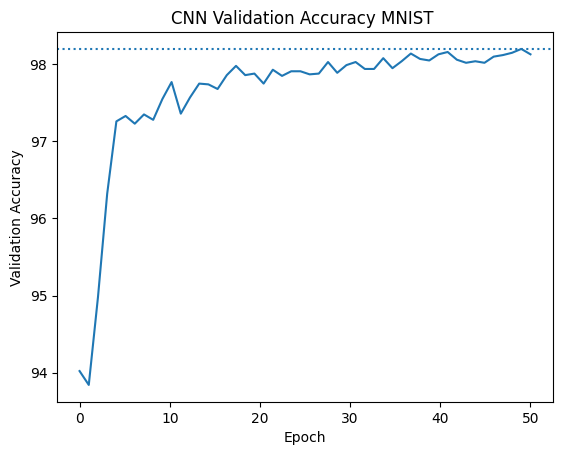

In [22]:
model1 = CNN()
GraphAccuracy(TRAIN_loader, TEST_loader, model1, "MNIST")


Graph Accuracy Over Time for Fashion MNIST Dataset

Epoch: 0, Test Accuracy: 85.43
Epoch: 1, Test Accuracy: 87.04
Epoch: 2, Test Accuracy: 87.67
Epoch: 3, Test Accuracy: 88.52
Epoch: 4, Test Accuracy: 88.35
Epoch: 5, Test Accuracy: 89.29
Epoch: 6, Test Accuracy: 88.72
Epoch: 7, Test Accuracy: 88.97
Epoch: 8, Test Accuracy: 89.5
Epoch: 9, Test Accuracy: 89.3
Epoch: 10, Test Accuracy: 89.62
Epoch: 11, Test Accuracy: 89.43
Epoch: 12, Test Accuracy: 89.67
Epoch: 13, Test Accuracy: 89.39
Epoch: 14, Test Accuracy: 89.24
Epoch: 15, Test Accuracy: 89.71
Epoch: 16, Test Accuracy: 89.73
Epoch: 17, Test Accuracy: 89.32
Epoch: 18, Test Accuracy: 89.73
Epoch: 19, Test Accuracy: 89.85
Epoch: 20, Test Accuracy: 89.35
Epoch: 21, Test Accuracy: 89.74
Epoch: 22, Test Accuracy: 89.53
Epoch: 23, Test Accuracy: 89.67
Epoch: 24, Test Accuracy: 89.4
Epoch: 25, Test Accuracy: 90.06
Epoch: 26, Test Accuracy: 89.12
Epoch: 27, Test Accuracy: 88.58
Epoch: 28, Test Accuracy: 89.17
Epoch: 29, Test Accuracy: 89.56
Epoch: 30, Test Accuracy: 89.15
Epoch: 31, Test Accur

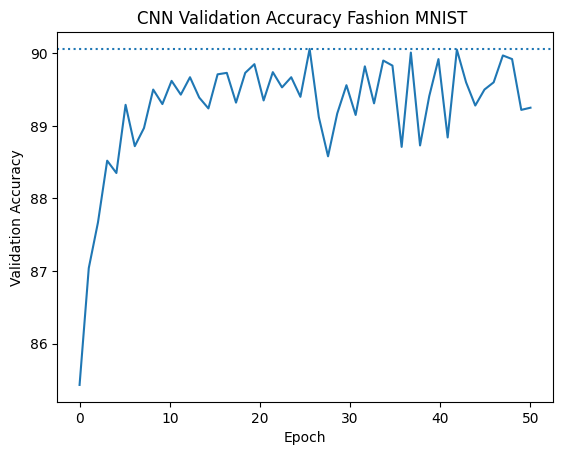

In [23]:
model2 = CNN()
GraphAccuracy(TRAIN_loader1, TEST_loader1, model2, "Fashion MNIST")